# Calidad de datos -  Burnout Work From Home

1. Integración de los datos
2. Eliminar variables irrelevantes y redundantes matemática
3. Descripción estadística de los datos
4. Limpieza de datos atípicos-errores
5. Limpieza de datos nulos
6. Análisis de correlaciones para redundancias entre todas las variables
7. Análisis de correlaciones para irrelevancias respecto a la objetivo
8. Guardar los datos preparados


In [29]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica


# 1. Integración de Datos


In [30]:
# Se cargan los datos de la tabla 1
data = pd.read_csv("work_from_home_burnout_dataset.csv")
data.head()


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [31]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [32]:
#Revisamos si tenemos ID repetidos
ids = data['user_id'].value_counts()
ids[ids > 1]


user_id
1      10
2      10
3      10
4      10
5      10
       ..
176    10
177    10
178    10
179    10
180    10
Name: count, Length: 180, dtype: int64

Los valores repetidos en `user_id` no se eliminan porque representan varias observaciones del mismo usuario en días diferentes. No corresponden a duplicados del registro completo.


In [33]:
#Verificamos registros duplicados completos
data.duplicated().sum()


np.int64(0)

In [34]:
#Corrección del tipo de datos object a categorías
data['day_type']=data['day_type'].astype('category')
data['after_hours_work']=data['after_hours_work'].astype('category')
data['burnout_risk']=data['burnout_risk'].astype('category')

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   user_id               1800 non-null   int64   
 1   day_type              1800 non-null   category
 2   work_hours            1800 non-null   float64 
 3   screen_time_hours     1800 non-null   float64 
 4   meetings_count        1800 non-null   int64   
 5   breaks_taken          1800 non-null   int64   
 6   after_hours_work      1800 non-null   category
 7   sleep_hours           1800 non-null   float64 
 8   task_completion_rate  1800 non-null   float64 
 9   burnout_score         1800 non-null   float64 
 10  burnout_risk          1800 non-null   category
dtypes: category(3), float64(5), int64(3)
memory usage: 118.3 KB


# 2. Eliminar variables irrelevantes y redundantes
* Irrelevantes: cedulas, ids, nombres, telefonos, direcciones, códigos.
* Redundantes: validación por fórmula matemática que están repetidas


In [35]:
# Variables irrelevantes para el proceso de minería
data = data.drop('user_id',axis=1) #Eliminamos el ID por ser irrelevante, axis=1 indica que es una columna
data.head()


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


# 3. Descripción estadística


In [36]:
data.describe()


,work_hours,screen_time_hours,meetings_count,breaks_taken,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,6.515117,9.271406,1.941111,3.028889,6.996467,72.308556,44.009978
std,2.290521,2.409253,1.696178,1.417844,1.061740,14.978647,23.881782
min,3.000000,4.510000,0.000000,1.000000,4.500000,40.000000,2.500000
25%,4.430000,7.240000,1.000000,2.000000,6.280000,62.300000,25.370000
50%,6.445000,9.210000,2.000000,3.000000,6.990000,74.500000,39.270000
75%,8.510000,11.310000,3.000000,4.000000,7.750000,83.700000,58.197500
max,12.170000,15.700000,10.000000,5.000000,10.800000,107.200000,143.920000


**Variables numéricas**


array([[<Axes: title={'center': 'work_hours'}>,
        <Axes: title={'center': 'screen_time_hours'}>,
        <Axes: title={'center': 'meetings_count'}>],
       [<Axes: title={'center': 'breaks_taken'}>,
        <Axes: title={'center': 'sleep_hours'}>,
        <Axes: title={'center': 'task_completion_rate'}>],
       [<Axes: title={'center': 'burnout_score'}>, <Axes: >, <Axes: >]],
      dtype=object)

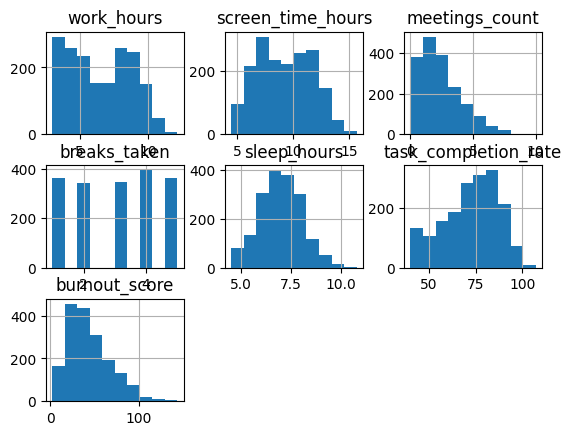

In [37]:
data.hist()


<Axes: >

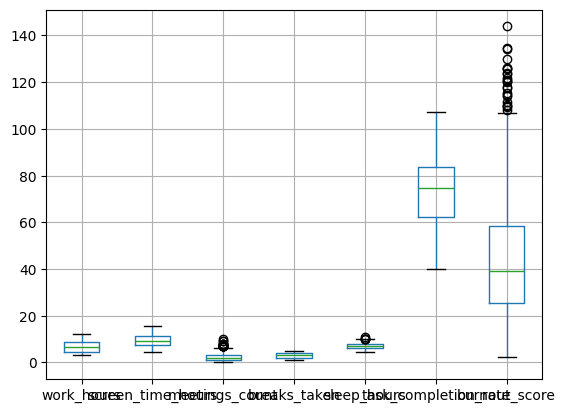

In [38]:
data.boxplot()


**Variables categóricas** (value_counts())


<Axes: xlabel='day_type'>

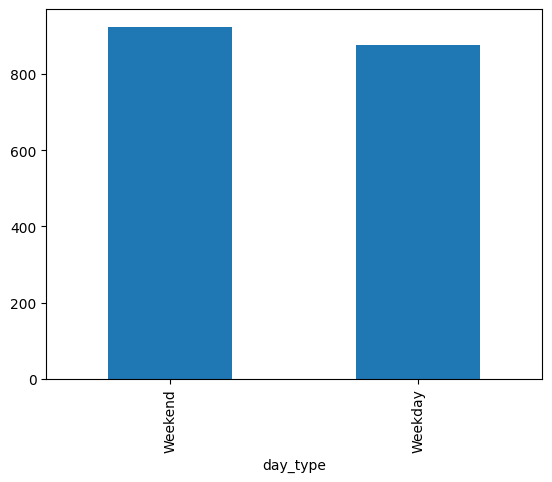

In [39]:
#Conocemos las variables categóricas: bar, barh, pie
data['day_type'].value_counts().plot(kind='bar')


<Axes: ylabel='count'>

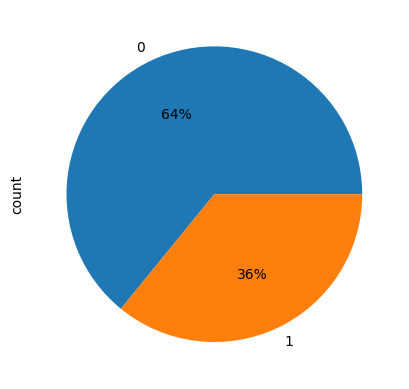

In [40]:
data['after_hours_work'].value_counts().plot(kind='pie',autopct='%.0f%%')


<Axes: ylabel='burnout_risk'>

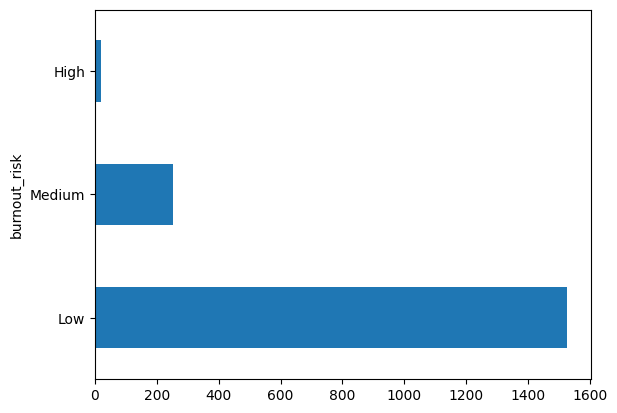

In [41]:
data['burnout_risk'].value_counts().plot(kind='barh')


**Gráficas de las relaciones entre variables**


<Axes: xlabel='work_hours', ylabel='burnout_score'>

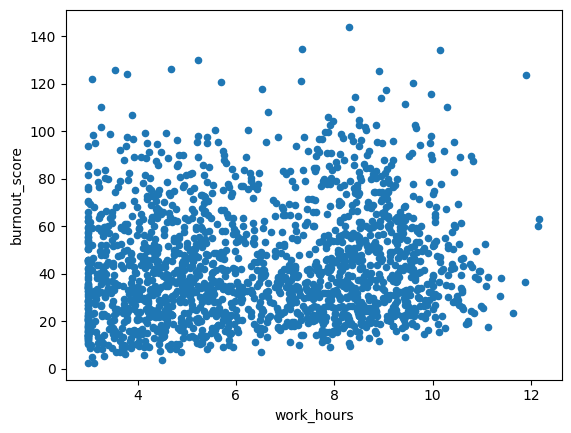

In [42]:
data.plot.scatter(x='work_hours',y='burnout_score')


<Axes: xlabel='sleep_hours', ylabel='burnout_score'>

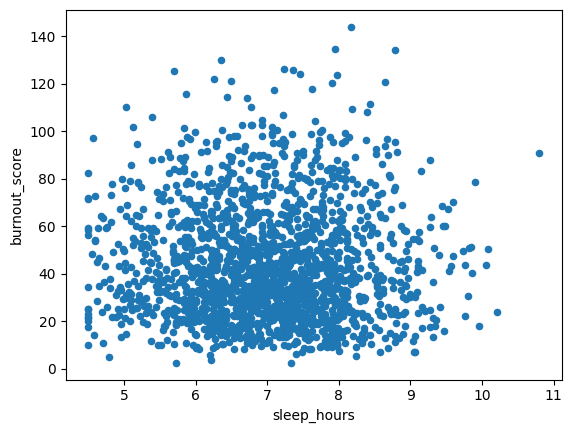

In [43]:
data.plot.scatter(x='sleep_hours',y='burnout_score')


**Perfilado de datos**


In [44]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=True
profile_data


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 28747.80it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [45]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="perfilado_burnout.html")


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Dimensiones de la Calidad de Datos**

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:**¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados? Ejemplo: Una fecha en formato AAAA/MM/DD cuando debería ser DD/MM/AAAA.

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?


# **Diagnóstico de las dimensiones según el perfilado:**
* Completitud: no existen missing en las variables del conjunto de datos original.
* Exactitud: existen valores fuera del rango esperado en `task_completion_rate` y `burnout_score`, porque son porcentajes o puntajes que no deberían superar 100.
* Conformidad: las variables `day_type`, `after_hours_work` y `burnout_risk` fueron convertidas a categoría para conservar el formato esperado.
* Oportunidad: no se puede verificar porque el conjunto de datos no contiene fecha de captura o actualización.
* Duplicidad: no existen registros duplicados completos. El `user_id` se repite porque cada usuario tiene varias observaciones.
* Integridad: el conjunto de datos contiene las variables necesarias para analizar el riesgo de burnout; no se evidencian relaciones faltantes con otras tablas.


# 4. Limpieza de datos atípicos-errores
- Sólo se limpian errores


In [46]:
#Se asigna valor nulo a los atípicos

data.loc[data["task_completion_rate"]>100, "task_completion_rate"]=np.nan #data.loc[filas, col]
data.loc[data["burnout_score"]>100, "burnout_score"]=np.nan #data.loc[filas, col]
data.describe()


,work_hours,screen_time_hours,meetings_count,breaks_taken,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1790.000000,1763.000000
mean,6.515117,9.271406,1.941111,3.028889,6.996467,72.141117,42.541480
std,2.290521,2.409253,1.696178,1.417844,1.061740,14.850500,21.786896
min,3.000000,4.510000,0.000000,1.000000,4.500000,40.000000,2.500000
25%,4.430000,7.240000,1.000000,2.000000,6.280000,62.225000,25.180000
50%,6.445000,9.210000,2.000000,3.000000,6.990000,74.400000,38.450000
75%,8.510000,11.310000,3.000000,4.000000,7.750000,83.600000,56.520000
max,12.170000,15.700000,10.000000,5.000000,10.800000,100.000000,99.690000


**5. Limpieza de datos nulos: Imputación**

Estrategia:
* Eliminar registros con mas de 15% de nulos
* Eliminar columnas con mas de 15%-20% de nulos
* Imputar por media, moda, mediana, vecinos cercanos. No se puede imputar más allá del 15% de los datos.
* Para casos especiales se crea modelo predictivo


In [47]:
#Limpieza de datos nulos: Imputación por la media y moda
from sklearn.impute import SimpleImputer

#Imputacion de variables numéricas: media, mediana
var_numericas = ['task_completion_rate','burnout_score']
ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='mean')
data[var_numericas] = ImpNumeros.fit_transform(data[var_numericas])

#Imputacion de variables categóricas: moda
var_categoricas = ['day_type','after_hours_work','burnout_risk']
ImpCategorias = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data[var_categoricas] = ImpCategorias.fit_transform(data[var_categoricas])

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   day_type              1800 non-null   object 
 1   work_hours            1800 non-null   float64
 2   screen_time_hours     1800 non-null   float64
 3   meetings_count        1800 non-null   int64  
 4   breaks_taken          1800 non-null   int64  
 5   after_hours_work      1800 non-null   object 
 6   sleep_hours           1800 non-null   float64
 7   task_completion_rate  1800 non-null   float64
 8   burnout_score         1800 non-null   float64
 9   burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(2), object(3)
memory usage: 140.8+ KB


In [48]:
#Valores de la imputación
print(ImpNumeros.statistics_) #['task_completion_rate','burnout_score']
print(ImpCategorias.statistics_) # day_type, after_hours_work, burnout_risk


[72.14111732 42.54148043]
['Weekend' 0 'Low']


In [49]:
#Verificamos valores nulos después de la imputación
data.isnull().sum()


day_type                0
work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

# 6. Correlaciones para redundancias


In [50]:
# Todas las variables deben ser numéricas para calcular las correlaciones
# Se crean dummies para las variables categóricas
# Si la variable tiene dos categorías se usa drop_first=True
# Si la variable tiene tres o más categorías se usa drop_first=False

var_binarias = ['day_type','after_hours_work']
var_categoricas = ['burnout_risk']

data_binarias = pd.get_dummies(data[var_binarias], drop_first=True, dtype=int)
data_categoricas = pd.get_dummies(data[var_categoricas], drop_first=False, dtype=int)

data_num = pd.concat([data.drop(var_binarias + var_categoricas,axis=1), data_binarias, data_categoricas], axis=1)
data_num.head()


,work_hours,screen_time_hours,meetings_count,breaks_taken,sleep_hours,task_completion_rate,burnout_score,day_type_Weekend,after_hours_work_1,burnout_risk_High,burnout_risk_Low,burnout_risk_Medium
0,9.59,11.86,4,2,7.55,91.2,19.17,0,0,0,1,0
1,7.38,10.33,4,1,6.69,82.0,29.70,1,0,0,1,0
2,6.31,8.92,1,2,8.87,80.6,32.93,1,0,0,1,0
3,8.34,10.70,4,1,8.13,70.0,45.47,0,1,0,1,0
4,6.97,9.83,1,2,5.85,67.1,51.61,1,0,0,1,0


**Correlaciones para redundacia= mayores |0.8|**


In [51]:
#Correlaciones
correlaciones=data_num.corr()
correlaciones


,work_hours,screen_time_hours,meetings_count,breaks_taken,sleep_hours,task_completion_rate,burnout_score,day_type_Weekend,after_hours_work_1,burnout_risk_High,burnout_risk_Low,burnout_risk_Medium
work_hours,1.000000,0.954373,0.517326,0.016343,0.011896,-0.112065,1.049525e-01,-0.868396,-0.015308,5.079837e-02,-0.051880,0.038222
screen_time_hours,0.954373,1.000000,0.490042,0.003195,0.001836,-0.115577,1.079850e-01,-0.833372,-0.009111,4.973453e-02,-0.055119,0.041885
meetings_count,0.517326,0.490042,1.000000,0.024284,0.023003,-0.092066,7.508391e-02,-0.577865,0.007542,2.555993e-02,-0.032951,0.026298
breaks_taken,0.016343,0.003195,0.024284,1.000000,0.011965,-0.000033,-5.978654e-04,-0.027989,0.039497,2.027423e-02,-0.001217,-0.004859
sleep_hours,0.011896,0.001836,0.023003,0.011965,1.000000,0.015886,-1.281162e-02,-0.017493,-0.000074,2.641726e-02,0.002036,-0.010069
task_completion_rate,-0.112065,-0.115577,-0.092066,-0.000033,0.015886,1.000000,-9.075866e-01,0.108934,-0.030054,-2.301209e-01,0.721535,-0.675248
burnout_score,0.104952,0.107985,0.075084,-0.000598,-0.012812,-0.907587,1.000000e+00,-0.094736,0.021235,-1.508794e-16,-0.680329,0.702125
day_type_Weekend,-0.868396,-0.833372,-0.577865,-0.027989,-0.017493,0.108934,-9.473581e-02,1.000000,0.010165,-5.584642e-02,0.059310,-0.044367
after_hours_work_1,-0.015308,-0.009111,0.007542,0.039497,-0.000074,-0.030054,2.123488e-02,0.010165,1.000000,-1.964291e-03,0.003154,-0.002662
burnout_risk_High,0.050798,0.049735,0.025560,0.020274,0.026417,-0.230121,-1.508794e-16,-0.055846,-0.001964,1.000000e+00,-0.250694,-0.042867


<Axes: >

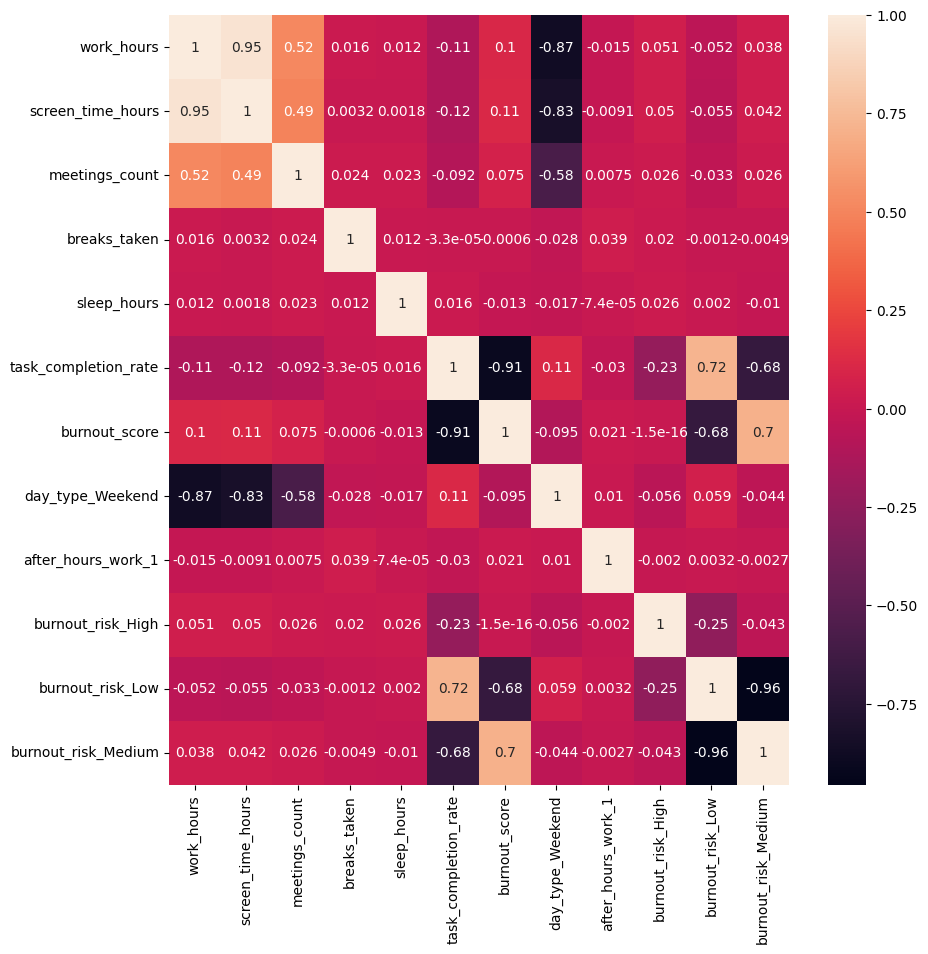

In [52]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(data_num.corr(),annot=True)


# 7. Correlaciones para irrelevancia con la variable objetivo

Se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05 ) ->ultima fila


In [53]:
#Correlaciones con la variable de objetivo
cor_variable_obj=correlaciones.loc['burnout_score']
cor_variable_obj


work_hours              1.049525e-01
screen_time_hours       1.079850e-01
meetings_count          7.508391e-02
breaks_taken           -5.978654e-04
sleep_hours            -1.281162e-02
task_completion_rate   -9.075866e-01
burnout_score           1.000000e+00
day_type_Weekend       -9.473581e-02
after_hours_work_1      2.123488e-02
burnout_risk_High      -1.508794e-16
burnout_risk_Low       -6.803294e-01
burnout_risk_Medium     7.021254e-01
Name: burnout_score, dtype: float64

# **Redundancias e irrelevancias:**
* Redundancia: `screen_time_hours` presenta una correlación alta con `work_hours` (mayor a |0.8|), por lo tanto se elimina `screen_time_hours` y se conserva `work_hours`.
* Redundancia: `day_type_Weekend` presenta una correlación alta con `work_hours` (mayor a |0.8|), por lo tanto se elimina la variable original `day_type` y se conserva `work_hours`.
* Redundancia: `task_completion_rate` y `burnout_score` tienen correlación alta, pero se conservan en calidad de datos porque la selección definitiva de la variable objetivo se realizará en minería de datos.
* Redundancia: las correlaciones altas asociadas a las categorías de `burnout_risk` corresponden a variables dummies creadas para el análisis, no a columnas originales repetidas.
* Irrelevancia: `breaks_taken`, `sleep_hours` y `after_hours_work_1` tienen correlación muy baja con `burnout_score` (0.0-0.05), por lo tanto se eliminan las variables originales `breaks_taken`, `sleep_hours` y `after_hours_work`.
* Irrelevancia: `burnout_risk_High` también presenta correlación muy baja con `burnout_score`, pero no se elimina la variable original `burnout_risk` porque puede ser la variable objetivo para el modelo de clasificación.


In [54]:
#Detección de redundantes = se buscan correlaciones mayores a |0.8|

# Se elimina screen_time_hours por redundancia con work_hours
# Se elimina day_type por redundancia con work_hours
data = data.drop('screen_time_hours',axis=1)
data = data.drop('day_type',axis=1)
data.head()


,work_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,9.59,4,2,0,7.55,91.2,19.17,Low
1,7.38,4,1,0,6.69,82.0,29.70,Low
2,6.31,1,2,0,8.87,80.6,32.93,Low
3,8.34,4,1,1,8.13,70.0,45.47,Low
4,6.97,1,2,0,5.85,67.1,51.61,Low


In [55]:
#Detección de irrelevantes = se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05 ) ->ultima fila

data = data.drop('breaks_taken',axis=1)
data = data.drop('sleep_hours',axis=1)
data = data.drop('after_hours_work',axis=1)
data.head()


,work_hours,meetings_count,task_completion_rate,burnout_score,burnout_risk
0,9.59,4,91.2,19.17,Low
1,7.38,4,82.0,29.70,Low
2,6.31,1,80.6,32.93,Low
3,8.34,4,70.0,45.47,Low
4,6.97,1,67.1,51.61,Low


# 8. Guardar los datos preparados


In [56]:
data.to_csv('./datos_limpios_burnout.csv', index=False)
